In [463]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities, louvain_communities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

In [464]:
G = nx.read_edgelist("input_data/edges_train.edgelist", data=False, nodetype=int, delimiter=',')
attributes = pd.read_csv("input_data/attributes.csv", index_col="ID")["attribute"]

N = len(list(G.nodes))
E = len(list(G.edges))
print("The network has ", N, " nodes")
print("The network has ", E, " edges")

The network has  1800  nodes
The network has  6377  edges


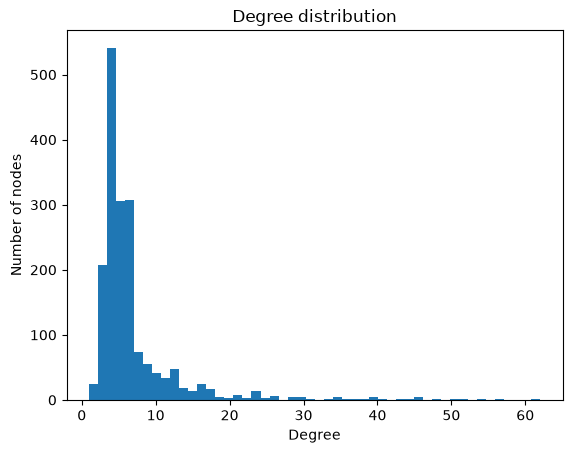

Average degree: 7.085555555555556
Average clustering coefficient: 0.10908775663792247


In [465]:
# Degree distribution
degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins=50)
plt.xlabel("Degree"); plt.ylabel("Number of nodes"); plt.title("Degree distribution")
plt.show()

print("Average degree:", np.mean(degrees))
print("Average clustering coefficient:", nx.average_clustering(G))

In [466]:
#remove 10% of edges randomly
nEdgesRemove = int(0.1 * E)

allEdges = np.array(G.edges)
np.random.seed(seed=42)
selectEdges = np.random.choice(np.arange(allEdges.shape[0]), nEdgesRemove, replace=False)
edgesToRemove = allEdges[selectEdges]

H = G.copy()
H.remove_edges_from(edgesToRemove)
print("H has", len(list(H.edges)), "edges")




H has 5740 edges


Number of communities: 7


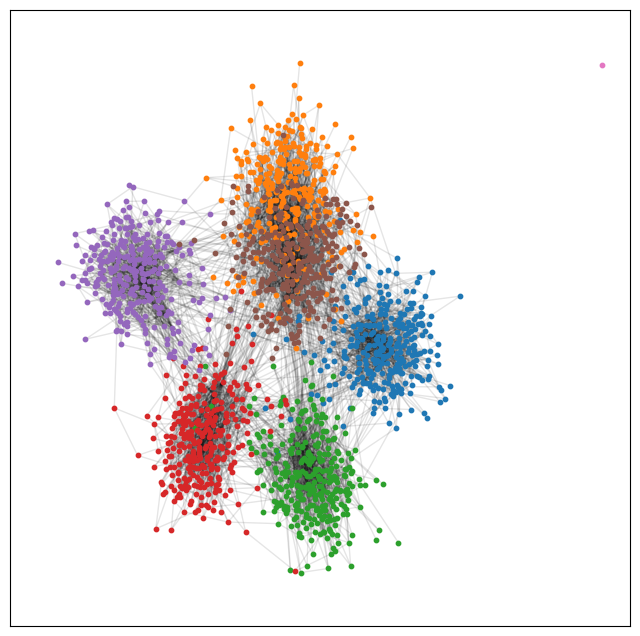

attribute,a,b,c,d,e,f
community,,,,,,
0,9,16,223,16,20,19
1,14,225,18,18,20,8
2,12,21,15,20,217,17
3,16,18,13,218,16,20
4,14,11,20,13,16,224
5,235,8,11,15,11,12
6,0,1,0,0,0,0


In [467]:
#Detecting communities

c = list(greedy_modularity_communities(H))
print("Number of communities:", len(c))

# Dictionary: node -> community number
community = {}
for k in range(len(c)):
    for node in c[k]:
        community[node] = k

# Plot the network coloured by community
pos = nx.spring_layout(H, seed=42)
plt.figure(figsize=(8, 8))
for k in range(len(c)):
    nx.draw_networkx_nodes(H, pos, nodelist=sorted(c[k]), node_size=10, node_color="C%d" % k)
nx.draw_networkx_edges(H, pos, alpha=0.1)
plt.show()

# Compare communities with the attribute
pd.crosstab(pd.Series(community, name="community"), attributes)

In [65]:
def getFeature(G, i, j):
    cn = len(list(nx.common_neighbors(G, i, j)))
    jac = list(nx.jaccard_coefficient(G, [(i, j)]))[0][2]
    aa = list(nx.adamic_adar_index(G, [(i, j)]))[0][2]
    pa = list(nx.preferential_attachment(G, [(i, j)]))[0][2]
    sameAttr = int(attributes[i] == attributes[j])
    sameComm = int(community[i] == community[j])
    return [cn, jac, aa, pa, sameAttr, sameComm]

In [454]:
#most features
def getFeature(G, i, j):
    # Common-friend features (clustering)
    cn = len(list(nx.common_neighbors(G, i, j)))
    jac = list(nx.jaccard_coefficient(G, [(i, j)]))[0][2]
    aa = list(nx.adamic_adar_index(G, [(i, j)]))[0][2]
    ra = list(nx.resource_allocation_index(G, [(i, j)]))[0][2]

    # Popularity features
    pa = list(nx.preferential_attachment(G, [(i, j)]))[0][2]
    degMin = min(G.degree(i), G.degree(j))
    degMax = max(G.degree(i), G.degree(j))

    # Distance in the network
    try:
        dist = nx.shortest_path_length(G, i, j)
    except nx.NetworkXNoPath:
        dist = 20          # no path at all (e.g. the isolated node in H)

    # Homophily and communities
    sameAttr = int(attributes[i] == attributes[j])
    sameComm = int(community[i] == community[j])

    return [cn, jac, aa, pa, sameAttr, sameComm, ra, dist, degMin, degMax]


featureNames = ["common_neighbors", "jaccard", "adamic_adar", "pref_attachment", "same_attribute",
                "same_community", "resource_allocation", "shortest_path", "degree_min", "degree_max"]

In [468]:
#New optimal
def getFeature(G, i, j):
    # Common-friend features (clustering)
    cn = len(list(nx.common_neighbors(G, i, j)))
    jac = list(nx.jaccard_coefficient(G, [(i, j)]))[0][2]
    aa = list(nx.adamic_adar_index(G, [(i, j)]))[0][2]

    # Popularity features
    pa = list(nx.preferential_attachment(G, [(i, j)]))[0][2]
    degMin = min(G.degree(i), G.degree(j))
    degMax = max(G.degree(i), G.degree(j))

    # Homophily and communities
    sameAttr = int(attributes[i] == attributes[j])
    sameComm = int(community[i] == community[j])

    return [cn, jac, aa, pa, sameAttr, sameComm, degMin, degMax]


featureNames = ["common_neighbors", "jaccard", "adamic_adar", "pref_attachment", "same_attribute",
                "same_community", "degree_min", "degree_max"]

In [142]:
#Only with the best features
def getFeature(G, i, j):
    sameComm = int(community[i] == community[j])          # communities
    cn = len(list(nx.common_neighbors(G, i, j)))          # shared friends (clustering)
    degMax = max(G.degree(i), G.degree(j))                # popularity of the more-connected person
    return [sameComm, cn, degMax]


featureNames = ["same_community", "common_neighbors", "degree_max"]

In [469]:
#Building the training data

X = []
Y = []

# Positive examplesthe removed edges
for (i, j) in edgesToRemove:
    X.append(getFeature(H, i, j))
    Y.append(1)

# Negative examples: pairs that are not connected
for kk in range(nEdgesRemove):
    i = np.random.randint(N)
    j = np.random.randint(N)
    while G.has_edge(i, j) or i == j:
        i = np.random.randint(N)
        j = np.random.randint(N)
    X.append(getFeature(H, i, j))
    Y.append(0)

print("Positive examples:", sum(Y), " Negative examples:", len(Y) - sum(Y))

Positive examples: 637  Negative examples: 637


In [282]:
# Average feature value for non-links (0) and links (1)
#featureNames = ["common_neighbors", "jaccard", "adamic_adar", "pref_attachment", "same_attribute", "same_community"]
#pd.DataFrame(X, columns=featureNames).groupby(Y).mean().T

# Train / Test split

In [470]:
X_train, X_test, y_train, y_test = train_test_split(np.array(X), np.array(Y), test_size=0.3, random_state=42, stratify=Y)

In [471]:
#tree depth
cvAcc = []
for d in range(1, 11):
    scores = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42), X_train, y_train, cv=5)
    cvAcc.append(scores.mean())
    print("max_depth = %d: %0.3f accuracy with a standard deviation of %0.3f" % (d, scores.mean(), scores.std()))

bestDepth = np.argmax(cvAcc) + 1
print("Best max_depth:", bestDepth)

max_depth = 1: 0.837 accuracy with a standard deviation of 0.013
max_depth = 2: 0.838 accuracy with a standard deviation of 0.009
max_depth = 3: 0.842 accuracy with a standard deviation of 0.011
max_depth = 4: 0.838 accuracy with a standard deviation of 0.009
max_depth = 5: 0.827 accuracy with a standard deviation of 0.015
max_depth = 6: 0.831 accuracy with a standard deviation of 0.016
max_depth = 7: 0.827 accuracy with a standard deviation of 0.019
max_depth = 8: 0.819 accuracy with a standard deviation of 0.014
max_depth = 9: 0.817 accuracy with a standard deviation of 0.013
max_depth = 10: 0.815 accuracy with a standard deviation of 0.016
Best max_depth: 3


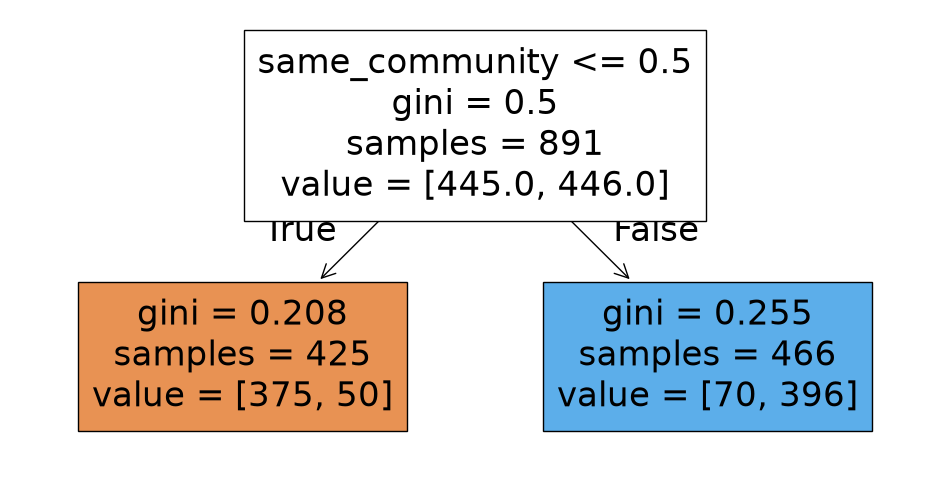

Test accuracy: 0.888


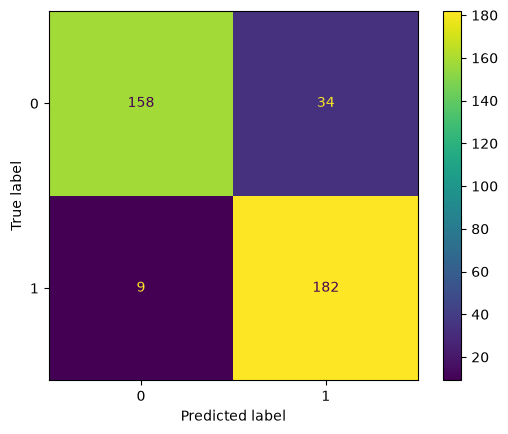

Sensitivity (TPR): 0.953
Specificity (TNR): 0.823
AUC: 0.888


In [459]:
# Train the decision tree classifier with the best depth and evaluate it on the test set

from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

model = DecisionTreeClassifier(max_depth=bestDepth, random_state=42)
decision_tree = model.fit(X_train, y_train)

plt.figure(figsize=(12, 6))
plot_tree(decision_tree, filled=True, feature_names=featureNames)
plt.show()

y_pred = model.predict(X_test)
print("Test accuracy: %.3f" % accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot()
plt.show()

TN, FP, FN, TP = cm.ravel()
print("Sensitivity (TPR): %.3f" % (TP / (TP + FN)))
print("Specificity (TNR): %.3f" % (TN / (TN + FP)))
print("AUC: %.3f" % roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

In [472]:
Xdf = pd.DataFrame(X, columns=featureNames)
for f in featureNames:
    print("%-18s AUC = %.3f" % (f, roc_auc_score(Y, Xdf[f])))

common_neighbors   AUC = 0.687
jaccard            AUC = 0.685
adamic_adar        AUC = 0.688
pref_attachment    AUC = 0.692
same_attribute     AUC = 0.684
same_community     AUC = 0.847
degree_min         AUC = 0.509
degree_max         AUC = 0.745


In [362]:
model = DecisionTreeClassifier(max_depth=bestDepth, random_state=42)

# All features
scores = cross_val_score(model, X_train, y_train, cv=5)
print("All features: %.3f" % scores.mean())

# Remove one feature at a time
for k in range(len(featureNames)):
    X_without = np.delete(X_train, k, axis=1)        # remove column k
    scores = cross_val_score(model, X_without, y_train, cv=5)
    print("Without %-20s %.3f" % (featureNames[k], scores.mean()))

All features: 0.865
Without common_neighbors     0.865
Without jaccard              0.865
Without adamic_adar          0.865
Without pref_attachment      0.865
Without same_attribute       0.865
Without same_community       0.677
Without degree_min           0.865
Without degree_max           0.865


featureNames = ["common_neighbors", "jaccard", "adamic_adar", "pref_attachment", "same_attribute",
                "same_community", "degree_min", "degree_max"]

In [190]:
pd.DataFrame(X, columns=featureNames).corr().round(2)

,common_neighbors,jaccard,adamic_adar,pref_attachment,same_attribute,same_community,degree_min,degree_max
common_neighbors,1.00,0.67,0.96,0.65,0.24,0.38,0.58,0.43
jaccard,0.67,1.00,0.64,0.15,0.24,0.38,0.15,0.08
adamic_adar,0.96,0.64,1.00,0.64,0.23,0.36,0.56,0.41
pref_attachment,0.65,0.15,0.64,1.00,0.15,0.19,0.90,0.60
same_attribute,0.24,0.24,0.23,0.15,1.00,0.51,0.13,0.17
same_community,0.38,0.38,0.36,0.19,0.51,1.00,0.12,0.32
degree_min,0.58,0.15,0.56,0.90,0.13,0.12,1.00,0.39
degree_max,0.43,0.08,0.41,0.60,0.17,0.32,0.39,1.00


In [473]:
#Predicting the real test pairs

from networkx.algorithms.community import greedy_modularity_communities


# Recompute communities on the full network G
c = list(greedy_modularity_communities(G))
community = {}
for k in range(len(c)):
    for node in c[k]:
        community[node] = k

inpTest = pd.read_csv('input_data/solutionInput.csv', sep=',', index_col="ID")
inpTest = np.array(inpTest)
inp = []
for i in inpTest:
    inp.append(getFeature(G, i[0], i[1]))

predictionsDT = model.predict(np.array(inp))
pd.DataFrame(predictionsDT).to_csv('solution_predictions.csv', index=True, header=["prediction"], index_label="ID")


ValueError: X has 8 features, but DecisionTreeClassifier is expecting 10 features as input.

In [462]:
# Predictions on the test set
y_pred = model.predict(X_test)
print("Test accuracy: %.3f" % accuracy_score(y_test, y_pred))

Test accuracy: 0.888


Original 0.856
With everything: 0.869
With new optimal: 0.888

# Random forest


In [31]:
from sklearn.ensemble import RandomForestClassifier

# 1. Choose max_depth with cross-validation
cvAccRF = []
for d in range(1, 11):
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    scores = cross_val_score(rf, X_train, y_train, cv=5)
    cvAccRF.append(scores.mean())
    print("max_depth = %d: %0.3f accuracy with a standard deviation of %0.3f" % (d, scores.mean(), scores.std()))

bestDepthRF = np.argmax(cvAccRF) + 1
print("Best max_depth (random forest):", bestDepthRF)

# 2. Train the final random forest and evaluate on the test set
rf = RandomForestClassifier(n_estimators=100, max_depth=bestDepthRF, random_state=42)
rf.fit(X_train, y_train)


max_depth = 1: 0.842 accuracy with a standard deviation of 0.017
max_depth = 2: 0.842 accuracy with a standard deviation of 0.017
max_depth = 3: 0.842 accuracy with a standard deviation of 0.016
max_depth = 4: 0.835 accuracy with a standard deviation of 0.013
max_depth = 5: 0.832 accuracy with a standard deviation of 0.019
max_depth = 6: 0.832 accuracy with a standard deviation of 0.021
max_depth = 7: 0.826 accuracy with a standard deviation of 0.014
max_depth = 8: 0.815 accuracy with a standard deviation of 0.017
max_depth = 9: 0.813 accuracy with a standard deviation of 0.020
max_depth = 10: 0.810 accuracy with a standard deviation of 0.020
Best max_depth (random forest): 3


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",np.int64(3)
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap 

In [36]:
y_predRF = rf.predict(X_test)
print("Random forest test accuracy: %.3f" % accuracy_score(y_test, y_predRF))


Random forest test accuracy: 0.867


In [ ]:
cmRF = confusion_matrix(y_test, y_predRF, labels=rf.classes_)
ConfusionMatrixDisplay(confusion_matrix=cmRF, display_labels=rf.classes_).plot()
plt.show()

TN, FP, FN, TP = cmRF.ravel()
print("Sensitivity (TPR): %.3f" % (TP / (TP + FN)))
print("Specificity (TNR): %.3f" % (TN / (TN + FP)))
print("AUC: %.3f" % roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

# 3. Feature importance (averaged over all trees)
print(pd.Series(rf.feature_importances_, index=featureNames).sort_values(ascending=False))

In [ ]:
Before running on Kaggle you can train on the whole dataset 
